## Objective

The objective of this notebook is to optimize the classification threshold of the selected Random Forest model trained with SMOTE. Instead of relying on the default probability threshold of 0.50, multiple thresholds will be evaluated to identify the best trade-off between fraud detection (Recall) and false alarms (Precision), based on business requirements.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Load Best Model

In [3]:
rf_smote_model = joblib.load(
    "../models/random_forest_smote.pkl"
)

## Load Test Data

In [4]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

## Predict Probabilities

In [5]:
y_prob = rf_smote_model.predict_proba(X_test)[:,1]

## Evaluate Multiple Thresholds

In [6]:
thresholds = np.arange(0.10, 0.95, 0.05)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    results.append([
        threshold,
        precision,
        recall,
        f1,
        fp,
        fn
    ])

In [7]:
threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ]
)

threshold_results

,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.10,0.349345,0.842105,0.493827,149,15
1,0.15,0.589552,0.831579,0.689956,55,16
2,0.20,0.709091,0.821053,0.760976,32,17
3,0.25,0.762376,0.810526,0.785714,24,18
4,0.30,0.810526,0.810526,0.810526,18,18
5,0.35,0.853933,0.800000,0.826087,13,19
6,0.40,0.892857,0.789474,0.837989,9,20
7,0.45,0.902439,0.778947,0.836158,8,21
8,0.50,0.913580,0.778947,0.840909,7,21
9,0.55,0.911392,0.757895,0.827586,7,23


## Plot Metrics

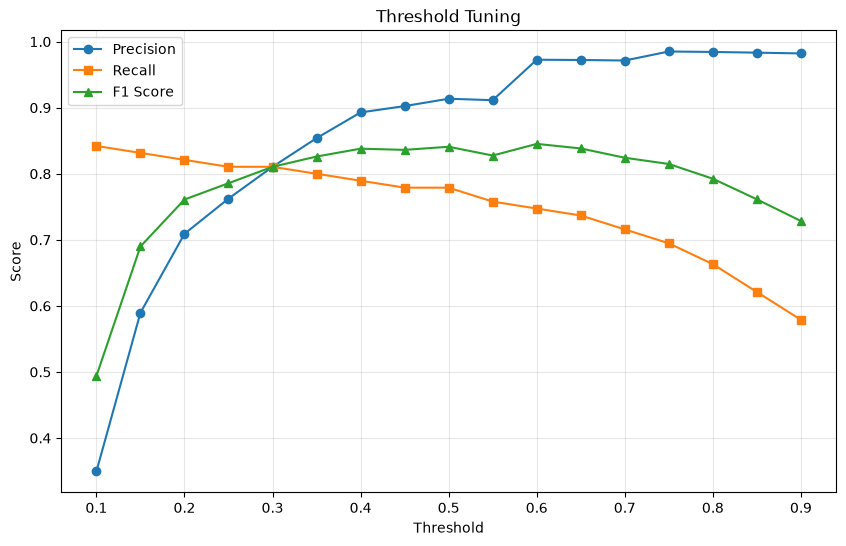

In [8]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="^",
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Tuning")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## Select Best Threshold

In [9]:
best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold

Threshold           0.600000
Precision           0.972603
Recall              0.747368
F1 Score            0.845238
False Positives     2.000000
False Negatives    24.000000
Name: 10, dtype: float64

## Save Results

In [10]:
threshold_results.to_csv(
    "../reports/threshold_tuning_results.csv",
    index=False
)

In [11]:
import joblib

joblib.dump(
    best_threshold["Threshold"],
    "../models/best_threshold.pkl"
)

['../models/best_threshold.pkl']

The default classification threshold of 0.50 was systematically evaluated against multiple alternative thresholds. By comparing Precision, Recall, F1-score, and the number of False Positives and False Negatives, the threshold providing the best balance for the fraud detection objective was selected. This optimized threshold will be used alongside the trained Random Forest model during deployment.